# Trabalho 01 - Apresentação

Análise de dados referente ao inventário de emissões atmosféricas do estado do Paraná de fontes fixas por diversos setores, disponibilizado pelo Instituto Água e Terra

Os dados são dos anos de 2023 e 2024 e o parâmetro escolhido é MPT

Requisitos:
- Operação com dados - leitura e manipulação
- Estatística univariada
- Estatística bivariada


## Importando pacotes, leitura dos arquivos e criação de um único DataFrame


In [214]:
# Automatizando Pacotes
import os
import pandas as pd
import matplotlib.pyplot as plt

#Listando os arquivos dentro da pasta de dados
files = os.listdir(r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\trabalho1")
files = [ fname for fname in files if fname.endswith('.csv')]
files

['Relatorio_Inventario_Completo_MPT_2023.csv',
 'Relatorio_Inventario_Completo_MPT_2024.csv']

In [215]:
# Crio uma lista vazia para juntar os dados de todos os arquivos em um único DataFrame
dfs = []

for file in files:
    print(file)
    # Abre o arquivo
    df = pd.read_csv(r"C:\Users\satiu\Documents\GitHub\python_env_app\dados\trabalho1" + "/" + file)
    # Agora adiciono o DataFrame df na lista dfs que eu criei
    dfs.append(df)

# Concatena todos os DataFrames (crio uma outra tabela com todas as informações das 2 tabelas)
df_all = pd.concat(dfs, ignore_index=True)

# Para ter noção do formato da tabela
df_all.head()

Relatorio_Inventario_Completo_MPT_2023.csv
Relatorio_Inventario_Completo_MPT_2024.csv


,Atividade,Atividade Específica,Município,Ano da Declaração,Órgão Emissor,Ponto de Emissão,Descrição Ponto de Emissão,Latitude,Longitude,Origem Emissão,Equipamento,Parâmetro,Combustível,VBS,Taxa ton/ano,Média taxa ton/ano
0,Ind. da madeira,"Fabricação de chapas, placas de madeira aglome...",Imbituva,2023,IAT,Chaminé,"Chaminé 2 - altura 12,00m / diâmetro 0,55m",-25.239494,-50.588894,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - silo de pó,MPT,NaN,3296,"2,94267",2.94267
1,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 2 - altura 2,00m / diâmetro 0,80m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - transport...,MPT,NaN,31115,"57,63120",57.63120
2,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 5 - altura 5,00m / diâmetro 1,10m",-25.934047,-53.482794,Exaustão de Material Particulado Total - MPT,Filtro Manga - coladeira de borda,MPT,NaN,50697,"118,24568",118.24568
3,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 1 - altura 7,00m / diâmetro 0,8m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - corte,MPT,NaN,21705,"43,17993",43.17993
4,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 3 - altura 5,00m / diâmetro 0,50m",-25.934048,-53.482715,Exaustão de Material Particulado Total - MPT,Filtro Manga - corte,MPT,NaN,6717,"19,35302",19.35302


In [216]:
# Converte a coluna 'Taxa ton/ano' para número (para realizarmos os cálculos)
df_all["Taxa ton/ano"] = (df_all["Taxa ton/ano"].astype(str).str.replace(",", ".", regex=False))
# Tenta converter para float — se algo não for número, vira NaN
df_all["Taxa ton/ano"] = pd.to_numeric(df_all["Taxa ton/ano"], errors="coerce")

df_all.head()

,Atividade,Atividade Específica,Município,Ano da Declaração,Órgão Emissor,Ponto de Emissão,Descrição Ponto de Emissão,Latitude,Longitude,Origem Emissão,Equipamento,Parâmetro,Combustível,VBS,Taxa ton/ano,Média taxa ton/ano
0,Ind. da madeira,"Fabricação de chapas, placas de madeira aglome...",Imbituva,2023,IAT,Chaminé,"Chaminé 2 - altura 12,00m / diâmetro 0,55m",-25.239494,-50.588894,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - silo de pó,MPT,NaN,3296,2.94267,2.94267
1,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 2 - altura 2,00m / diâmetro 0,80m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - transport...,MPT,NaN,31115,57.63120,57.63120
2,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 5 - altura 5,00m / diâmetro 1,10m",-25.934047,-53.482794,Exaustão de Material Particulado Total - MPT,Filtro Manga - coladeira de borda,MPT,NaN,50697,118.24568,118.24568
3,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 1 - altura 7,00m / diâmetro 0,8m",-25.934048,-53.482715,Exaustão de Pó de Madeira - Sistemas de Exaust...,Exaustão de pó de madeira/serragem - corte,MPT,NaN,21705,43.17993,43.17993
4,Ind. da madeira,Fabricação de estruturas de madeira e de móveis,Ampére,2023,IAT,Chaminé,"Chaminé 3 - altura 5,00m / diâmetro 0,50m",-25.934048,-53.482715,Exaustão de Material Particulado Total - MPT,Filtro Manga - corte,MPT,NaN,6717,19.35302,19.35302


## Comparação Geral de Emissão nos anos de 2023 e 2024

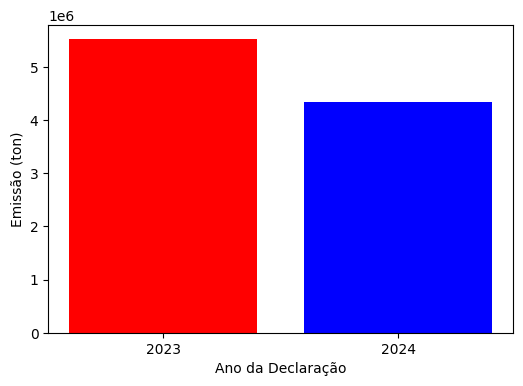

In [217]:
# Agrupa pelos valores da coluna 'Ano da Declaração'
df_grouped = df_all.groupby("Ano da Declaração")["Taxa ton/ano"].sum().reset_index()

# Cria o gráfico de barras comparando os anos
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_grouped["Ano da Declaração"], df_grouped["Taxa ton/ano"], color=['r', 'b'])

# Personalizações
ax.set_xlabel("Ano da Declaração")
ax.set_ylabel("Emissão (ton)")
ax.set_xticks(df_grouped["Ano da Declaração"])

# Salva o gráfico
fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\comparativo_taxa_cada_ano.png")

## Média de emissão por setor

In [218]:
# Estatísticas descritivas de emissões (por setor), inclui count, mean, std, min, 25%, 50%, 75%, max
estatisticas_setor = (df_all.groupby('Atividade')['Taxa ton/ano'].describe().round(2)) # arredonda os valores pra 2 casas decimais

estatisticas_setor

,count,mean,std,min,25%,50%,75%,max
Atividade,,,,,,,,
Alimentos,588.0,1154.21,3302.46,0.00,36.87,246.53,1198.95,50041.82
Armazenamento e atividades auxiliares dos transportes,30.0,64.49,70.35,0.00,10.95,39.63,91.89,274.54
Atividades funerárias e serviços relacionados,30.0,26.55,76.04,0.38,2.95,5.77,19.92,415.74
Avicultura,1.0,0.02,NaN,0.02,0.02,0.02,0.02,0.02
Base de distribuição,3.0,3.12,3.91,0.83,0.86,0.90,4.27,7.64
Bebidas,35.0,891.38,1276.19,2.31,8.71,169.34,1148.26,4938.06
Beneficiamento de mandioca,30.0,571.01,1183.83,5.99,31.92,122.93,610.14,5979.37
Beneficiamento de minerais não metálicos,247.0,746.32,2862.61,0.00,25.48,101.38,391.88,36822.30
Beneficiamento e armazenamento de produtos agrícolas,67.0,3179.50,22207.10,1.89,26.18,85.40,273.96,182068.37


In [219]:
import numpy as np

# Faz uma cópia pra não alterar o original
df_sem_outlier = df_all.copy()

# Remove outliers dentro de cada setor (Atividade)
for setor in df_sem_outlier['Atividade'].unique():
    # Calcula o 99º percentil dentro do setor
    limite = np.nanpercentile(df_sem_outlier.loc[df_sem_outlier['Atividade'] == setor, 'Taxa ton/ano'], 99)
    # Substitui valores acima do 99º percentil por NaN
    df_sem_outlier.loc[(df_sem_outlier['Atividade'] == setor) & (df_sem_outlier['Taxa ton/ano'] > limite),'Taxa ton/ano'] = np.nan


estatisticas_setor_sem_outlier = (df_sem_outlier.groupby('Atividade')['Taxa ton/ano'].describe().round(2))

estatisticas_setor_sem_outlier

,count,mean,std,min,25%,50%,75%,max
Atividade,,,,,,,,
Alimentos,582.0,910.18,1470.49,0.00,36.12,239.87,1175.91,8581.06
Armazenamento e atividades auxiliares dos transportes,29.0,57.24,59.12,0.00,8.52,35.04,84.94,198.08
Atividades funerárias e serviços relacionados,29.0,13.13,19.79,0.38,2.93,5.22,18.45,101.43
Avicultura,1.0,0.02,NaN,0.02,0.02,0.02,0.02,0.02
Base de distribuição,2.0,0.86,0.04,0.83,0.85,0.86,0.88,0.90
Bebidas,34.0,772.36,1080.36,2.31,8.54,167.23,1059.50,3101.82
Beneficiamento de mandioca,29.0,384.51,608.96,5.99,31.37,112.71,402.86,2458.39
Beneficiamento de minerais não metálicos,244.0,490.35,1190.16,0.00,25.30,100.91,357.89,11395.01
Beneficiamento e armazenamento de produtos agrícolas,66.0,469.06,977.79,1.89,23.65,84.43,264.44,4770.15


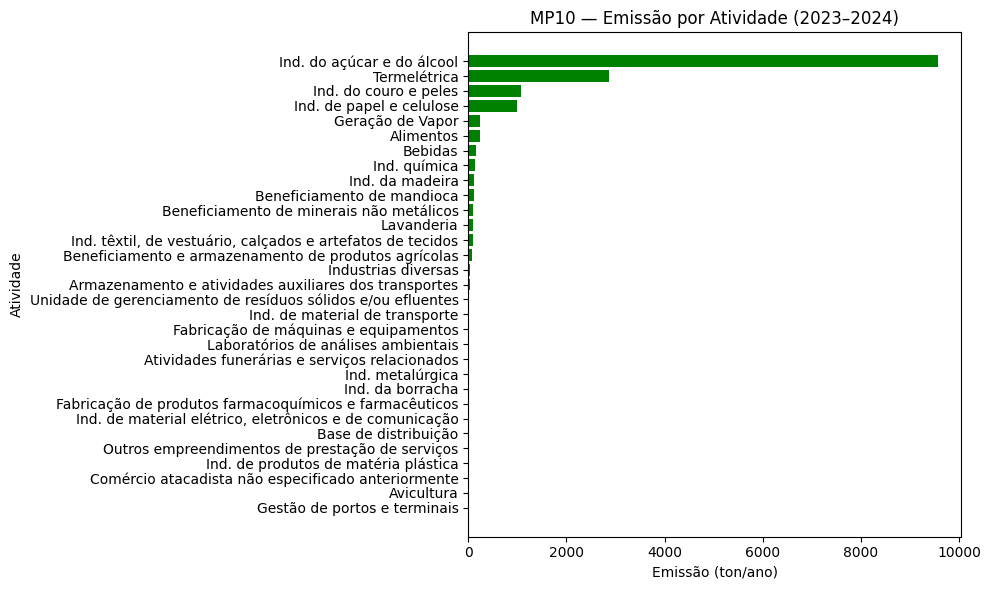

In [ ]:
# MÉDIA DE EMISSÃO POR ATIVIDADE (GERAL, 2023–2024 juntos)

# garante que só use as colunas necessárias e tira Atividade nula
df_tmp = df_sem_outlier[['Atividade', 'Taxa ton/ano']].copy()
df_tmp = df_tmp.dropna(subset=['Atividade'])

# Agrupa os setores, usa "as_index' para resultado voltar como DataFrame, fazemos a emissão média de cada atividade,
# Troquei o nome da coluna para facilitar entendimento, ".sort_values" ordena do maior para o menor.
media_por_atividade = (df_tmp.groupby('Atividade', as_index=False)['Taxa ton/ano'].median().rename(columns={'Taxa ton/ano': 'Emissão média (ton/ano)'}).sort_values('Emissão média (ton/ano)', ascending=False))


# Gráfico com todas as atividades
fig, ax = plt.subplots(figsize=(10,6))
# [::-1] uso para arrumar o gráfico depois que troquei bar para barh (quando troca a ordem de atividades fica errada)
ax.barh(media_por_atividade['Atividade'][::-1], media_por_atividade['Emissão média (ton/ano)'][::-1], color='g')
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.set_title('MP10 — Emissão por Atividade (2023–2024)')
fig.tight_layout()

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor.png")

# Gráfico com apenas atividades "médias"
filtro = media_por_atividade[media_por_atividade['Emissão média (ton/ano)'] < 5000]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(filtro['Atividade'][::-1], filtro['Emissão média (ton/ano)'][::-1], color='b')
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.set_title('MP10 — Indústrias com emissão < 5.000 ton/ano')
fig.tight_layout()

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor_mediano.png")

# Gráfico com apenas atividades pequenas
filtro = media_por_atividade[media_por_atividade['Emissão média (ton/ano)'] < 400]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(filtro['Atividade'][::-1], filtro['Emissão média (ton/ano)'][::-1], color='r')
ax.set_xlabel('Emissão (ton/ano)')
ax.set_ylabel('Atividade')
ax.set_title('MP10 — Indústrias com emissão < 400 ton/ano')
fig.tight_layout()

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor_pequeno.png")

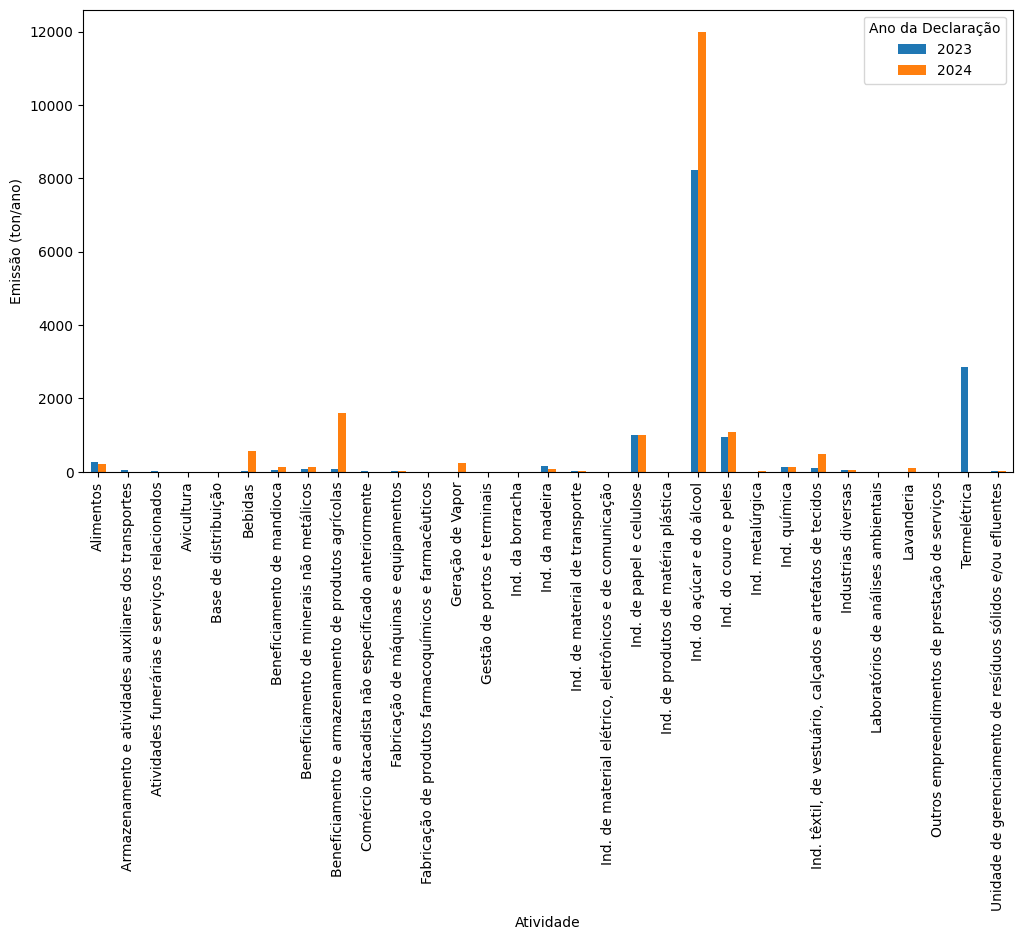

In [224]:
# MÉDIA POR ATIVIDADE EM CADA ANO (2023 vs 2024)

media_ano_atividade = (df_sem_outlier.groupby(['Ano da Declaração', 'Atividade'], as_index=False)['Taxa ton/ano'].median().rename(columns={'Taxa ton/ano': 'Emissão média (ton/ano)'}))

# Tabela comparativa lado a lado (todas as atividades)
# pivot(Atividade vira índice, coluna separada pra cada ano, conteúdo das células é a emissão média
comparativo = (media_ano_atividade.pivot(index='Atividade', columns='Ano da Declaração', values='Emissão média (ton/ano)').fillna(0)) # NaN = 0 

# Gráfico com todas as atividades
fig, ax = plt.subplots(figsize=(12, 6))
comparativo.plot(kind='bar', ax=ax)
ax.set_xlabel('Atividade')
ax.set_ylabel('Emissão (ton/ano)')
ax.legend(title='Ano da Declaração')

fig.savefig(r"C:\Users\satiu\Documents\GitHub\python_env_app\output\MP10\Emissao_por_setor_comparativo_anos.png")